# 3교시 | Attention 이해 + LLM(Large Language Model) 구조 이해 (통합)
**환경**: Google Colab | **방법**: 이론 + 실습
> 2교시에서 확인한 GPT-2 구조를 바탕으로, Attention 메커니즘과 텍스트 생성 루프를 연속으로 실습한다.

---

## 학습 목표

- Self-Attention의 Q·K·V 수식과 직관적 의미를 설명할 수 있다.
- Attention Map을 시각화하여 모델이 어떤 토큰에 집중하는지 해석한다.
- Decoder-only 아키텍처의 Autoregressive 생성 루프를 직접 구현한다.
- 생성 과정에서 각 스텝의 상위 후보 토큰과 확률을 출력할 수 있다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: Attention으로 문맥을 읽는 과정과 다음 토큰을 생성하는 과정이 사실 하나의 모델 안에서 연결되어 있음을 이해하는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: Attention Map은 "어디를 봤는지", 생성 루프는 "무엇을 뽑았는지"를 보여 준다고 이해하면 된다.
- 헷갈려도 괜찮은 부분: hidden state, logits, probabilities는 처음엔 비슷해 보일 수 있다. 먼저 "내부 표현 → 점수 → 확률" 순서만 기억하면 된다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| Q, K, V | 무엇을 찾는지, 어떤 특징인지, 실제 전달 정보가 무엇인지 나타내는 벡터 |
| Attention Map | 모델이 어느 토큰을 더 많이 참고했는지 보여 주는 그림 |
| Hidden State | 모델 내부에서 현재 토큰이 가진 의미 표현 |
| Logits | 다음 토큰 후보들에 대한 원시 점수 |
| Probability | softmax를 거쳐 해석 가능한 선택 확률로 바뀐 값 |
| Decoder-only | 이전 토큰만 보고 다음 토큰을 생성하는 구조 |

---

## 이론 (전반부 — Attention)

### 먼저 큰 흐름 잡기

이번 차시는 두 가지를 하나로 연결해서 이해하는 것이 핵심이다.

1. Attention은 각 토큰이 다른 토큰을 얼마나 참고할지 계산하는 메커니즘이다.
2. LLM은 그 Attention 계산 결과를 바탕으로 다음 토큰을 하나씩 생성한다.

즉, Attention은 "문맥을 읽는 방법"이고, LLM 생성은 "읽은 문맥으로 다음 단어를 고르는 과정"이다.  
이 연결이 잡히면 수식, Attention Map, 생성 루프가 따로따로 보이지 않고 하나의 흐름으로 이해된다.

### Self-Attention 수식

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q (Query)**: "나는 무엇을 찾고 있는가?" — 현재 토큰의 질문 벡터
- **K (Key)**: "나는 어떤 정보를 갖고 있는가?" — 각 토큰의 레이블 벡터
- **V (Value)**: "실제로 전달할 내용은?" — 각 토큰의 값 벡터
- $\sqrt{d_k}$로 나누는 이유: 차원이 커질수록 내적값이 커져 softmax가 포화(saturation)되는 현상 방지

처음 공부할 때는 이 수식을 "유사도 계산 → 중요도 정규화 → 정보 합성"의 3단계로 보는 것이 좋다.

1. $QK^T$: 지금 토큰이 다른 토큰들과 얼마나 관련 있는지 점수 계산
2. `softmax`: 그 점수를 0과 1 사이의 가중치처럼 변환
3. $V$와 곱하기: 중요한 토큰의 정보를 더 많이 반영해 새로운 표현 생성

**직관적 이해**

```
문장: "The cat sat on the mat because it was tired."

"it"이 어떤 단어를 참조하는지 파악하려면?
→ Q("it")와 K("cat"), K("mat")의 유사도를 계산
→ 유사도가 높은 V("cat")의 정보를 더 많이 취합
→ 대명사 해소(Coreference Resolution)
```

여기서 중요한 점은 모델이 단순히 "가장 가까운 단어"를 보는 것이 아니라, **현재 토큰을 이해하는 데 실제로 도움이 되는 토큰**을 더 강하게 본다는 점이다.

### Multi-Head Attention

단일 Attention은 하나의 관점만 포착한다. 여러 헤드(GPT-2: 12개)로 **다양한 관계를 병렬로** 학습한다.

| 헤드 역할 예시 | 내용 |
|---|---|
| 문법적 의존성 | 주어-동사 관계 파악 |
| 의미적 유사성 | 같은 개념을 가진 단어 연결 |
| 위치적 근접성 | 바로 앞/뒤 단어 참조 |
| 대명사 해소 | 대명사와 원래 명사 연결 |

실제로는 각 Head가 사람이 이름표를 붙이듯 깔끔하게 분리되지는 않지만, 여러 Head를 두면 모델이 한 가지 관계만 보지 않고 다양한 패턴을 동시에 포착할 수 있다.

### Causal (Masked) Self-Attention

GPT 계열은 미래 토큰을 볼 수 없도록 상삼각 행렬을 `-∞`로 마스킹한다.

```
현재 토큰 →      The   cat   sat   on
참조 가능 토큰
The           [  ✅    ❌    ❌    ❌ ]
cat           [  ✅    ✅    ❌    ❌ ]
sat           [  ✅    ✅    ✅    ❌ ]
on            [  ✅    ✅    ✅    ✅ ]
```

이 표는 아래 의미로 읽으면 된다.

- `sat`을 계산할 때는 `The`, `cat`, `sat`까지만 볼 수 있다.
- `on`을 계산할 때는 앞선 모든 토큰을 볼 수 있다.
- 어떤 위치도 자기 오른쪽, 즉 미래 토큰은 볼 수 없다.

이 제약이 있어야 모델이 학습 중에도 생성 시점과 같은 조건을 유지한다.

---

## 이론 (LLM 구조)

### Decoder-only 아키텍처

GPT 계열(GPT-2/3/4, LLaMA, Gemma, Mistral 등)이 채택한 구조다.

- Encoder 없이 **Causal Self-Attention만으로** 구성
- 파라미터 효율적이고 생성 태스크에 최적화
- 입력(프롬프트) + 이미 생성된 토큰을 **항상 전체 시퀀스로** 재처리

교육생이 꼭 기억해야 할 포인트는, GPT가 문장을 한 번에 완성해서 내는 것이 아니라 **매 스텝마다 다음 토큰 하나만 예측한다**는 점이다.  
긴 문장도 내부적으로는 이 한 단계 예측을 매우 빠르게 반복한 결과다.

### Next-Token Prediction 흐름

```
입력: "The sky is"
  ↓
Token Embedding + Positional Encoding
  ↓
12개 Transformer Block (Causal Attention)
  ↓
LM Head(Language Modeling Head): Linear(768 → 50,257)
  ↓
Softmax → 50,257개 단어에 대한 확률 분포
  ↓
"blue" 선택 (확률: 0.23)
  ↓
다시 전체 시퀀스 "The sky is blue" 입력 → 반복
```

이 흐름을 말로 풀면 다음과 같다.

1. 현재까지의 문장을 모델에 넣는다.
2. 마지막 위치에서 "다음에 올 토큰"의 확률 분포를 얻는다.
3. 그중 하나를 선택한다.
4. 선택한 토큰을 원래 문장 뒤에 붙인다.
5. 이 과정을 종료 조건(EOS 또는 최대 길이)까지 반복한다.

즉, LLM 생성은 사실상 **"확률 분포를 계속 다시 계산하는 반복문"** 이다.

### LM Head(Language Modeling Head)의 역할

```text
GPT-2의 LM Head(Language Modeling Head) 구조
Linear(in_features=768, out_features=50257)
- d_model(768) → vocab_size(50,257) 투영
- 출력값(logits)이 클수록 해당 토큰 선택 확률이 높음
```

여기서 `logits`는 아직 확률이 아니다.  
Softmax를 통과한 뒤에야 각 토큰이 선택될 상대적 가능성으로 해석할 수 있다.

즉, LM Head(Language Modeling Head)가 필요한 이유는 모델 내부의 문맥 표현(`hidden state`)을 사람이 실제로 고를 수 있는 어휘 후보 공간(`vocab_size`)으로 바꿔 주어야 다음 토큰을 선택할 수 있기 때문이다.

이 구분은 중요하다.

- `hidden state`: 문맥 정보가 담긴 벡터 표현
- `logits`: 각 토큰 후보에 대한 점수
- `probabilities`: softmax 이후의 확률 분포

### Attention과 생성 루프의 연결

이번 차시를 관통하는 핵심 문장은 아래와 같다.

> Attention은 "문맥을 계산"하고, LM Head(Language Modeling Head)는 그 문맥을 "다음 토큰 점수"로 바꾼다.

즉, 각 Transformer Block에서 Attention으로 문맥 표현을 만들고, 마지막에 LM Head(Language Modeling Head)가 그 표현을 어휘 전체에 대한 점수로 변환한다. 그래서 Attention Map을 보는 활동과 생성 루프를 구현하는 활동은 사실 하나의 모델을 서로 다른 각도에서 보는 것이다.

---

## 실습

### 자주 막히는 오류

- Attention 텐서 shape가 낯설다: 먼저 `layer`, `head`, `query 위치`, `key 위치` 순서로 생각하면 해석이 쉽다.
- 특정 토큰 attention이 기대와 다름: head와 layer마다 보는 관계가 다르므로 항상 같은 패턴이 나오지 않아도 정상이다.
- 생성 결과가 매번 다름: sampling 설정이 들어가 있으면 결과가 달라질 수 있다.
- `it`이 꼭 원하는 단어만 보지 않음: Attention은 하나의 head 결과만으로 전체 의미를 단정하기 어렵다.

### 실패했을 때 체크 순서

1. 지금 보는 값이 무엇인지 먼저 구분한다: Attention map인지, hidden state인지, logits인지부터 확인한다.
2. 텐서 축 순서를 다시 읽는다: layer, head, token 위치를 잘못 읽으면 해석이 바로 어긋난다.
3. 한 단계 앞 셀부터 다시 실행한다: Attention 시각화와 생성 루프는 중간 변수에 의존하므로 직전 단계부터 복구한다.

실습은 2교시와 마찬가지로 **한 단계씩 순서대로 실행**하는 것을 권장한다.  
이번 차시는 크게 두 부분으로 나뉜다.

1. Part A: Attention Map을 보고 모델이 어디에 주목하는지 해석하기
2. Part B: 다음 토큰 생성 루프를 직접 구현해 보기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행하고 출력 결과를 확인한 뒤 다음 셀로 넘어가면 된다.

### Part A — Attention Map 시각화

#### Step A0. 실습 준비

먼저 필요한 패키지를 설치하고 import한다.  
시각화에는 `matplotlib`, `seaborn`을 사용하고, 모델은 GPT-2를 그대로 활용한다.

In [1]:
!pip install -q transformers torch matplotlib seaborn

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel



이 단계에서 확인할 점:

- 패키지 설치 오류가 없는가?
- import가 정상적으로 되는가?

#### Step A1. 모델과 토크나이저 로드

Attention Map을 보려면 `output_attentions=True`로 모델을 불러와야 한다.

In [2]:
model_name = "gpt2"

# 토크나이저: 텍스트를 토큰 ID로 변환
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 모델: attention 가중치를 함께 반환하도록 설정
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

print("모델 로드 완료")
print(f"모델명: {model_name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료
모델명: gpt2




이 단계에서 확인할 점:

- 모델이 정상적으로 로드되는가?
- 추후 `outputs.attentions`를 볼 준비가 되었는가?

#### Step A2. 예제 문장을 토큰화하고 모델에 넣기

이 단계에서는 문장을 토큰화하고, attention 가중치가 포함된 출력을 받아온다.

In [3]:
text = "The cat sat on the mat because it was tired."

# 문장을 모델 입력 텐서로 변환
inputs = tokenizer(text, return_tensors="pt")

# 토큰 ID를 사람이 읽을 수 있는 문자열 토큰으로 복원
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

print(f"입력 문장: {text}")
print(f"토큰: {tokens}")
print(f"레이어 수: {len(outputs.attentions)}")
print(f"각 레이어 attention shape: {outputs.attentions[0].shape}")

입력 문장: The cat sat on the mat because it was tired.
토큰: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']
레이어 수: 12
각 레이어 attention shape: torch.Size([1, 12, 11, 11])


이 단계에서 확인할 점:

- 토큰 리스트에 `Ġcat`, `Ġsat`, `Ġit`처럼 `Ġ`가 붙은 항목이 보이면, 이것은 "앞에 공백이 있는 토큰"이라는 뜻으로 읽는다. 즉 `Ġit`은 실제로는 ` it`에 가깝다.
- 토큰 개수를 직접 세어 보면 이 문장은 `The`, `Ġcat`, `Ġsat`, `Ġon`, `Ġthe`, `Ġmat`, `Ġbecause`, `Ġit`, `Ġwas`, `Ġtired`, `.`까지 총 11개 토큰으로 나뉜다. 그래서 attention shape의 뒤 두 숫자도 `11, 11`로 나타난다.
- `레이어 수: 12`는 GPT-2 Small이 12개 Transformer 레이어를 가진다는 뜻이다. 즉, `outputs.attentions` 안에는 레이어별 attention 행렬이 12개 들어 있다.
- `torch.Size([1, 12, 11, 11])`는 순서대로 `batch_size=1`, `head 수=12`, `query 토큰 수=11`, `key 토큰 수=11`로 읽으면 된다.
- 마지막의 `11 x 11`은 "각 토큰이 문장 안의 11개 토큰을 어떻게 참고하는지"를 나타내는 attention 표라고 이해하면 된다. 즉, 한 레이어 안에서 토큰-토큰 관계를 담은 정사각 행렬이다.

#### Step A3. 특정 레이어와 헤드의 Attention Map 그리기

이제 하나의 head를 골라 heatmap으로 시각화한다.  
처음에는 마지막 레이어의 첫 번째 head를 보는 것이 가장 직관적이다.

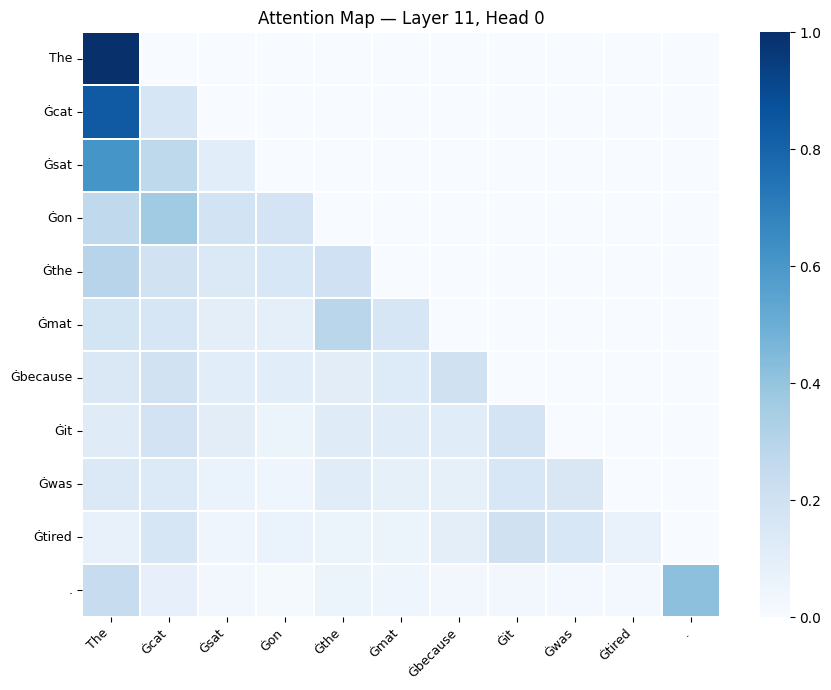

In [4]:
def plot_attention(layer_idx, head_idx):
    # 선택한 레이어/헤드의 attention 행렬 추출
    attn = outputs.attentions[layer_idx][0, head_idx].detach().numpy()

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="Blues",
        vmin=0,
        vmax=attn.max(),
        annot=False,
        linewidths=0.3,
    )
    plt.title(f"Attention Map — Layer {layer_idx}, Head {head_idx}")
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

# 마지막 레이어의 첫 번째 헤드 시각화
plot_attention(layer_idx=11, head_idx=0)

이 단계에서 확인할 점:

- heatmap의 **세로축 행**은 "현재 보고 있는 토큰(query)"이고, **가로축 열**은 "그 토큰이 참고한 대상 토큰(key)"이라고 읽는다. 즉, 어떤 행을 볼 때는 "이 토큰이 누구를 봤는가"를 읽는 것이다.
- 색이 진할수록 attention 값이 크다는 뜻이다. 따라서 진한 칸은 "그 행의 토큰이 그 열의 토큰을 더 강하게 참고했다"고 해석하면 된다.
- 결과처럼 주로 **왼쪽 아래 삼각형 쪽**에 색이 나타나는 것은 GPT의 Causal Mask 때문이라고 이해한다. 현재 토큰은 자기보다 오른쪽, 즉 미래 토큰을 볼 수 없으므로 오른쪽 위는 비어 있거나 매우 옅게 보인다.
- 대각선 부근이 비교적 진하면, 많은 토큰이 자기 자신 또는 바로 가까운 이전 토큰을 많이 참고하고 있다는 뜻으로 읽을 수 있다. 이것은 언어 모델에서 자주 나타나는 자연스러운 패턴이다.
- 모든 칸이 비슷한 색이 아니라 특정 행과 특정 열에서 더 진한 부분이 보인다면, 모델이 문장 전체를 똑같이 보는 것이 아니라 일부 토큰 관계에 더 집중하고 있다는 뜻이다. 즉, heatmap은 "문맥을 고르게 보는 것"이 아니라 "선택적으로 참고하는 것"을 보여 준다.

#### Step A4. 대명사 `it`이 어디를 보는지 분석하기

이번 단계에서는 heatmap을 눈으로만 보는 대신, `it` 토큰이 가장 많이 주목한 상위 토큰을 숫자로 확인한다.

In [5]:
print("\n[대명사 'it' Attention 분석]")

# GPT-2 BPE에서는 공백을 포함한 단어가 Ġit 형태로 나타난다.
it_idx = tokens.index("Ġit")

for layer in [0, 5, 11]:
    for head in range(3):
        # 'it' 행에서 attention 가중치 추출
        attn_row = outputs.attentions[layer][0, head, it_idx].detach()

        # 가장 크게 본 토큰 3개 선택
        top3 = torch.topk(attn_row, 3)
        top3_tokens = [tokens[i] for i in top3.indices.tolist()]

        print(
            f"  Layer {layer:2d}, Head {head}: "
            f"top3 = {list(zip(top3_tokens, top3.values.tolist()))}"
        )


[대명사 'it' Attention 분석]
  Layer  0, Head 0: top3 = [('Ġmat', 0.2833288013935089), ('The', 0.24807336926460266), ('Ġsat', 0.15490569174289703)]
  Layer  0, Head 1: top3 = [('Ġit', 0.9614775776863098), ('Ġthe', 0.020962851122021675), ('The', 0.008331499062478542)]
  Layer  0, Head 2: top3 = [('The', 0.31543558835983276), ('Ġbecause', 0.2116510421037674), ('Ġon', 0.15914572775363922)]
  Layer  5, Head 0: top3 = [('The', 0.784311830997467), ('Ġbecause', 0.13380101323127747), ('Ġit', 0.02493102289736271)]
  Layer  5, Head 1: top3 = [('The', 0.9846768975257874), ('Ġit', 0.009310773573815823), ('Ġsat', 0.003753719851374626)]
  Layer  5, Head 2: top3 = [('The', 0.4724038243293762), ('Ġbecause', 0.15819020569324493), ('Ġsat', 0.13444288074970245)]
  Layer 11, Head 0: top3 = [('Ġcat', 0.18492843210697174), ('Ġit', 0.17758619785308838), ('Ġthe', 0.11934277415275574)]
  Layer 11, Head 1: top3 = [('The', 0.9281489253044128), ('Ġsat', 0.018779505044221878), ('Ġit', 0.013973724097013474)]
  Layer 11

이 단계에서 확인할 점:

- 한 줄은 `"Layer 몇 번, Head 몇 번에서 Ġit 토큰이 가장 많이 참고한 상위 3개 토큰"`을 뜻한다. 예를 들어 `Layer 0, Head 1: ('Ġit', 0.961...)`은, 그 head에서는 `it`이 거의 자기 자신을 가장 강하게 보고 있다고 읽으면 된다.
- 토큰 이름 옆 숫자는 attention의 크기다. 값이 클수록 더 많이 참고했다는 뜻이다. 예를 들어 `0.96`은 매우 강한 집중이고, `0.18`, `0.11`처럼 비슷한 값들이 나오면 여러 토큰에 attention이 나뉘어 있다고 볼 수 있다.
- 출력 결과를 보면 어떤 head는 `Ġmat`을 많이 보고, 어떤 head는 `The`를 많이 보고, 어떤 head는 `Ġcat`을 비교적 높게 본다. 이것은 `it`의 해석이 하나의 고정 규칙으로 처리되는 것이 아니라, head마다 서로 다른 관점에서 문맥을 읽고 있음을 보여 준다.
- `it`이 항상 `cat`만 강하게 보지 않는다고 해서 이상한 것은 아니다. Attention은 "정답 단어 하나만 찍는 장치"가 아니라, 현재 토큰을 이해하는 데 도움이 되는 여러 위치를 가중치로 참고하는 메커니즘이기 때문이다.
- 얕은 층(Layer 0)과 중간 층(Layer 5), 깊은 층(Layer 11)의 상위 토큰이 달라지는지도 본다. 이런 차이는 층이 깊어질수록 문맥 표현이 바뀌고, 각 층이 맡는 역할도 조금씩 달라질 수 있음을 보여 준다.
- 특히 이 결과에서는 Layer 11, Head 0에서 `Ġcat`이 가장 높게 나오므로, 깊은 층 일부 head에서는 `it`이 `cat`과의 관계를 비교적 더 강하게 보는 해석도 가능하다. 다만 다른 head들은 `The`나 `Ġit` 자체에 더 큰 값을 줄 수 있으므로, 반드시 한 head만 보고 전체 의미를 단정하지 않는 것이 중요하다.

**관찰 과제**
1. `"it"`이 `"cat"`과 `"mat"` 중 어디에 더 주목하는지 확인
2. Layer 0(얕은 층)과 Layer 11(깊은 층)의 패턴 차이 비교
3. 여러 헤드의 역할이 서로 다른지 관찰

---

### Part B — Autoregressive 생성 루프 직접 구현

#### Step B0. LM Head(Language Modeling Head)가 포함된 모델 준비

이번에는 다음 토큰 생성까지 보기 위해 `GPT2LMHeadModel`을 사용한다.  
앞의 `AutoModel`은 히든 스테이트 중심이었고, 지금 모델은 마지막에 `lm_head`를 통해 토큰 점수까지 계산한다.

In [6]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

In [7]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
lm_model = GPT2LMHeadModel.from_pretrained("gpt2")
lm_model.eval()

print("LM Head(Language Modeling Head) 포함 모델 로드 완료")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LM Head(Language Modeling Head) 포함 모델 로드 완료




이 단계에서 확인할 점:

- 모델이 정상적으로 로드되는가?
- 이제 `logits`를 직접 볼 준비가 되었는가?

#### Step B1. LM Head(Language Modeling Head) 구조 확인

LM Head(Language Modeling Head)는 마지막 히든 스테이트를 어휘 전체에 대한 점수로 바꾸는 선형층이다.

In [8]:
print("[LM Head(Language Modeling Head) 구조]")
print(lm_model.lm_head)
print(f"입력 차원: {lm_model.lm_head.in_features}")
print(f"출력 차원: {lm_model.lm_head.out_features} (= vocab_size)")

[LM Head(Language Modeling Head) 구조]
Linear(in_features=768, out_features=50257, bias=False)
입력 차원: 768
출력 차원: 50257 (= vocab_size)


이 단계에서 확인할 점:

- `Linear(in_features=768, out_features=50257, bias=False)`는 LM Head(Language Modeling Head)가 **768차원 hidden state를 받아서 50,257개 어휘 후보에 대한 점수로 바꾼다**는 뜻으로 읽는다. 즉, 입력은 "문맥 표현 벡터"이고 출력은 "단어 후보별 점수표"다.
- `입력 차원: 768`은 GPT-2 Small의 한 토큰이 마지막 층에서 가지는 표현 길이라고 이해하면 된다. 다시 말해, 모델은 각 토큰을 내부적으로 길이 768의 숫자 벡터로 표현하고 있다.
- `출력 차원: 50257 (= vocab_size)`는 GPT-2가 고를 수 있는 전체 토큰 종류 수를 뜻한다. 즉, LM Head(Language Modeling Head)는 마지막에 "후보가 몇 개인가"를 세는 것이 아니라, **어휘 사전에 있는 모든 토큰에 대해 점수를 한 번에 계산**하는 층이다.
- 그래서 이 단계의 핵심은 `768 → 50257`이라는 숫자 변화 자체보다, **내부 의미 표현(hidden state)이 실제 다음 토큰 후보 점수(logits)로 변환되는 마지막 출구가 LM Head(Language Modeling Head)** 라는 점을 이해하는 것이다.
- 아직 이 값들은 확률이 아니라 점수(logits)다. 다음 단계에서 softmax를 적용해야 비로소 "어떤 토큰이 얼마나 가능성 높은가"를 확률처럼 해석할 수 있다.

#### Step B2. 프롬프트를 준비하고 첫 입력 형태 보기

이제 생성의 출발점이 되는 프롬프트를 준비한다.

In [9]:
prompt = "The future of artificial intelligence is"

# 프롬프트를 토큰 ID 텐서로 변환
generated = tokenizer.encode(prompt, return_tensors="pt")

print(f"프롬프트: {prompt}")
print(f"입력 shape: {generated.shape}")
print(f"입력 ID: {generated.tolist()[0]}")

프롬프트: The future of artificial intelligence is
입력 shape: torch.Size([1, 6])
입력 ID: [464, 2003, 286, 11666, 4430, 318]


이 단계에서 확인할 점:

- `입력 shape: torch.Size([1, 6])`는 "배치에 문장 1개가 들어 있고, 그 문장이 6개의 토큰으로 나뉘었다"는 뜻으로 읽는다. 즉, 여기서 `1`은 문장 개수(batch size), `6`은 토큰 개수(sequence length)다.
- `입력 ID: [464, 2003, 286, 11666, 4430, 318]`처럼 보이는 숫자들은 모델이 단어를 직접 읽는 대신 사용하는 **토큰 번호표**라고 이해하면 된다. 모델 내부에서는 문자열이 아니라 이런 정수 ID 형태로 계산이 진행된다.
- 원래 프롬프트 `The future of artificial intelligence is`가 한 글자씩 잘린 것이 아니라, GPT-2 토크나이저 기준의 6개 토큰으로 나뉜 것이다. 즉, 사람이 보는 단어 수와 모델이 처리하는 토큰 수가 항상 완전히 같지는 않을 수 있다.
- 지금 단계의 핵심은 "문장을 바로 넣는 것"이 아니라, **문장을 숫자 ID 시퀀스로 바꿔 모델 입력 텐서로 준비하는 것**이다. 이후 생성 루프는 이 숫자 시퀀스 뒤에 새 토큰 ID를 계속 붙여 가며 동작한다.
- 따라서 이 출력은 아직 "생성 결과"가 아니라, 생성이 시작되기 전의 **초기 입력 상태**를 보여 주는 것이다. 즉, 모델이 다음 토큰을 예측하기 위해 현재까지 받은 문맥이 무엇인지 확인하는 단계라고 이해하면 된다.

#### Step B3. 한 스텝의 다음 토큰 확률 보기

수동 생성 루프 전체를 돌리기 전에, 먼저 한 번만 실행해서 마지막 위치의 logits와 확률 분포를 확인한다.

In [20]:
with torch.no_grad():
    outputs = lm_model(generated)

# 마지막 위치의 logits만 가져온다.
logits = outputs.logits[:, -1, :]      # shape: (1, vocab_size)
probs = torch.softmax(logits, dim=-1)  # shape: (1, vocab_size)

top5_probs, top5_ids = torch.topk(probs[0], 5)
top5_tokens = [tokenizer.decode([token_id]) for token_id in top5_ids.tolist()]

print("[다음 토큰 상위 5개 후보]")
for rank, (tok, prob) in enumerate(zip(top5_tokens, top5_probs.tolist()), 1):
    print(f"{rank}. {repr(tok)} -> {prob:.4f}")

[다음 토큰 상위 5개 후보]
1. ' uncertain' -> 0.0766
2. ' in' -> 0.0694
3. ' not' -> 0.0441
4. ' a' -> 0.0407
5. ' still' -> 0.0345


이 단계에서 확인할 점:

- 출력의 각 줄은 "지금 프롬프트 뒤에 바로 올 수 있다고 모델이 생각한 다음 토큰 후보"를 뜻한다. 예를 들어 `1. ' uncertain' -> 0.0766`은 현재 문맥에서 ` uncertain`이 가장 유력한 후보로 계산되었다는 의미다.
- 따옴표 안 토큰 앞에 공백이 포함되어 보이는 것은 정상이다. GPT-2 토크나이저는 ` in`, ` not`, ` still`처럼 **앞 공백까지 포함한 토큰**을 자주 사용하므로, 이것은 문장 뒤에 자연스럽게 이어 붙일 단어 조각이라고 이해하면 된다.
- 숫자는 확률(probability)이다. 다만 여기서는 1등 후보도 `0.0766`, 즉 약 7.66% 정도이므로 모델이 "정답은 이것 하나다"라고 강하게 확신하는 상황은 아니다. 여러 후보를 동시에 그럴듯하게 보고 있다고 읽는 것이 맞다.
- `uncertain`, `in`, `not`, `a`, `still`처럼 서로 다른 종류의 후보가 함께 나온다는 것은, 프롬프트 `The future of artificial intelligence is` 뒤에 이어질 문장이 한 방향으로만 정해지지 않았다는 뜻이다. 즉, 모델은 형용사, 전치사, 부정 표현 등 여러 문장 전개 가능성을 동시에 열어 두고 있다.
- 이 단계의 핵심은 "모델이 다음 단어 하나를 바로 내놓는다"가 아니라, **먼저 전체 어휘에 대한 확률 분포를 만들고 그중 상위 후보들을 비교한다**는 점을 이해하는 것이다. 다음 단계의 Greedy 생성은 여기서 1등 후보만 골라 실제로 붙이는 과정이다.

#### Step B4. Greedy 방식으로 생성 루프 직접 구현하기

이제 매 스텝마다 가장 높은 확률 토큰을 선택하는 Greedy 생성 루프를 직접 구현한다.

In [21]:
generated = tokenizer.encode(prompt, return_tensors="pt")

print(f"\n[프롬프트] {prompt}")
print("-" * 55)

for step in range(20):
    with torch.no_grad():
        outputs = lm_model(generated)

    # 마지막 토큰 위치의 logits만 사용
    logits = outputs.logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)

    # 상위 5개 후보 확인
    top5_probs, top5_ids = torch.topk(probs[0], 5)
    top5_tokens = [tokenizer.decode([token_id]) for token_id in top5_ids.tolist()]

    # Greedy: 1등 토큰 선택
    next_id = top5_ids[0].unsqueeze(0).unsqueeze(0)
    chosen = tokenizer.decode(next_id[0])

    print(
        f"Step {step+1:2d} | 선택: {repr(chosen)} ({top5_probs[0]:.3f}) | "
        f"후보: {list(zip(top5_tokens, [f'{p:.3f}' for p in top5_probs.tolist()]))}"
    )

    # 선택한 토큰을 기존 시퀀스 뒤에 붙인다.
    generated = torch.cat([generated, next_id], dim=1)

    # EOS가 나오면 생성 종료
    if next_id.item() == tokenizer.eos_token_id:
        print("  → EOS 토큰 생성, 종료")
        break


[프롬프트] The future of artificial intelligence is
-------------------------------------------------------
Step  1 | 선택: ' uncertain' (0.077) | 후보: [(' uncertain', '0.077'), (' in', '0.069'), (' not', '0.044'), (' a', '0.041'), (' still', '0.034')]
Step  2 | 선택: '.' (0.380) | 후보: [('.', '0.380'), (',', '0.297'), (',"', '0.058'), ('."', '0.046'), (' and', '0.039')]
Step  3 | 선택: '\n' (0.076) | 후보: [('\n', '0.076'), (' The', '0.073'), (' But', '0.072'), (' It', '0.055'), (' In', '0.044')]
Step  4 | 선택: '\n' (0.999) | 후보: [('\n', '0.999'), ('.', '0.000'), ('"', '0.000'), ('The', '0.000'), ('<|endoftext|>', '0.000')]
Step  5 | 선택: '"' (0.098) | 후보: [('"', '0.098'), ('The', '0.081'), ('In', '0.052'), ('But', '0.032'), ('A', '0.025')]
Step  6 | 선택: 'We' (0.128) | 후보: [('We', '0.128'), ('I', '0.107'), ('The', '0.092'), ('It', '0.087'), ('There', '0.086')]
Step  7 | 선택: "'re" (0.206) | 후보: [("'re", '0.206'), (' are', '0.126'), (' have', '0.099'), (' don', '0.071'), ("'ve", '0.062')]
Step  8 | 선택

이 단계에서 확인할 점:

- 출력의 한 줄은 "현재까지 만든 문장 뒤에 다음 토큰 1개를 고른 기록"이라고 읽는다. 예를 들어 `Step 1 | 선택: ' uncertain' (0.077)`은, 첫 번째 생성 시점에서 모델이 가장 높은 후보로 ` uncertain`을 골라 문장 뒤에 붙였다는 뜻이다.
- `선택:` 뒤의 토큰은 실제로 붙인 토큰이고, `후보:` 뒤 목록은 그 순간 모델이 고려한 상위 후보들이다. Greedy 방식은 이 후보들 중에서 **항상 1등만 선택**하므로, `uncertain`, `.`, `\n`, `"`, `We`처럼 그때그때 가장 높은 점수를 받은 토큰이 순서대로 이어진다.
- 이 로그를 보면 생성은 정말로 **확률 계산 → 1등 선택 → 문장 뒤에 붙이기 → 다시 확률 계산**의 반복임을 확인할 수 있다. 즉, 모델이 한 번에 20개 토큰을 생각해서 쓰는 것이 아니라, 매 순간 다음 1개만 고르면서 문장을 점진적으로 만든다.
- 확률이 매우 큰 경우와 작은 경우를 구분해서 본다. 예를 들어 `Step 4`의 `\n (0.999)`나 `Step 15`의 ` like (0.999)`는 모델이 거의 확신한 선택이고, `Step 18`의 ` Dr (0.014)`처럼 값이 매우 작을 때는 상위 후보들끼리 점수 차이가 거의 없어 문장이 불안정하게 다른 방향으로 갈 수 있다.
- 그래서 Greedy라고 해서 항상 자연스러운 문장이 보장되지는 않는다. 초반에 ` uncertain`을 고른 뒤 `.`과 줄바꿈, 인용부호, `We`, `not sure what the future will look like," said Dr ...`처럼 문체가 갑자기 바뀌는 것은, 매 단계에서 "그 순간의 1등 후보"만 고르다 보니 전체 문장 흐름보다 국소적으로 가장 그럴듯한 패턴을 따라가기 때문이다.
- `\n`, `"`, `,'"` 같은 토큰이 보이는 것도 이상한 것이 아니다. 모델은 단어뿐 아니라 줄바꿈, 따옴표, 구두점까지 모두 토큰 후보로 다루므로, 생성 로그에는 문장 부호와 서식 토큰도 그대로 나타날 수 있다.

#### Step B5. 최종 생성 문장 확인하기

루프가 끝난 뒤, 전체 생성 결과를 사람이 읽을 수 있는 문자열로 복원한다.

In [22]:
final_text = tokenizer.decode(generated[0], skip_special_tokens=True)

print("\n[최종 출력]")
print(final_text)


[최종 출력]
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael


이 단계에서 확인할 점:

- 이 출력은 앞 단계에서 한 토큰씩 붙여 만든 결과를 사람이 읽을 수 있는 문장으로 다시 복원한 것이다. 즉, 지금 보이는 문장은 모델이 한 번에 쓴 문장이 아니라, Step 1부터 Step 20까지의 선택이 누적된 최종 결과다.
- 결과를 보면 첫 줄 `The future of artificial intelligence is uncertain.`까지는 비교적 자연스럽다. 하지만 그다음 줄에서 `"We're not sure what the future will look like," said Dr. Michael`처럼 갑자기 인용문과 화자 표현으로 이어진다. 이것은 모델이 전체 글의 계획을 세운 것이 아니라, 매 순간 가장 높은 확률 토큰을 이어 붙인 결과라고 이해하면 된다.
- 중간에 빈 줄이 들어간 이유는 앞 단계에서 `\n` 토큰이 두 번 선택되었기 때문이다. 즉, 최종 출력의 줄바꿈은 우연한 포맷 깨짐이 아니라, 생성 과정에서 줄바꿈 토큰 자체가 실제로 선택된 결과다.
- 문장이 완전히 끝맺히지 않고 `Dr. Michael`에서 멈춘 것도 이상한 것은 아니다. 우리는 최대 20개 토큰까지만 생성하도록 설정했기 때문에, 모델이 더 이어서 쓰고 싶어도 여기서 잘릴 수 있다. 즉, 최종 출력은 "완결된 글"이 아니라 **정해진 길이 안에서 잘린 생성 결과**일 수 있다.
- 이 단계의 핵심은 "최종 문장 품질 평가" 자체보다, **앞 단계의 개별 토큰 선택이 모여 실제 문장으로 어떻게 보이는지 확인하는 것**이다. 따라서 결과가 다소 어색하거나 문체가 갑자기 바뀌더라도, 그것은 생성 루프의 동작 원리를 보여 주는 좋은 관찰 포인트다.

#### Step B6. Greedy와 Sampling 결과 비교하기

마지막으로, 라이브러리의 `generate()`를 사용해 Greedy와 Sampling 결과를 비교한다.  
이 비교를 통해 같은 모델이라도 디코딩 전략에 따라 결과가 달라진다는 점을 확인할 수 있다.

In [26]:
print("\n[Greedy vs Sampling 비교]")

inputs = tokenizer(prompt, return_tensors="pt")

greedy = lm_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
)

sampled = lm_model.generate(
    **inputs,
    max_new_tokens=20,
    do_sample=True,
    temperature=0.9,
    pad_token_id=tokenizer.eos_token_id,
)

print(f"Greedy : {tokenizer.decode(greedy[0], skip_special_tokens=True)}")
print(f"Sampled: {tokenizer.decode(sampled[0], skip_special_tokens=True)}")


[Greedy vs Sampling 비교]
Greedy : The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael
Sampled: The future of artificial intelligence is now open to the public, with the launch of the AI-inspired Watson, Google's artificial intelligence


이 단계에서 확인할 점:

- `Greedy` 결과는 매 스텝마다 가장 확률이 높은 토큰만 고른 문장이다. 그래서 `The future of artificial intelligence is uncertain.`처럼 초반은 비교적 또렷하지만, 뒤에서는 줄바꿈과 인용문으로 갑자기 넘어가며 문체가 다소 딱딱하고 기계적으로 이어질 수 있다.
- `Sampled` 결과는 가장 높은 토큰만 고르는 대신, 확률 분포 안에서 하나를 뽑기 때문에 `is still uncertain, but in this current era of exponential growth, ...`처럼 더 길고 자연스럽게 이어지는 문장이 나올 수 있다. 즉, Sampling은 문장 전개가 더 유연하고 표현이 다양해지기 쉽다.
- 두 결과를 비교할 때 핵심은 "어느 쪽이 절대적으로 더 좋다"가 아니라, **같은 모델과 같은 프롬프트라도 디코딩 방식에 따라 출력 성격이 크게 달라진다**는 점을 확인하는 것이다.
- 이번 예시에서는 Greedy가 중간에 줄바꿈과 인용문 패턴으로 빠지면서 상대적으로 덜 자연스럽게 보이고, Sampling은 하나의 설명 문장처럼 이어지므로 더 매끄럽게 느껴질 수 있다. 하지만 Sampling도 매번 같은 결과가 나오지 않으며, 경우에 따라 더 산만하거나 덜 일관적인 문장이 나올 수도 있다.
- 따라서 이 단계의 핵심은 `Greedy = 안정적이지만 보수적`, `Sampling = 다양하지만 변동 가능성 있음`이라는 차이를 출력 예시와 연결해서 이해하는 것이다.

**관찰 과제**
1. Greedy와 Sampling 결과가 얼마나 다른지 확인
2. 각 스텝에서 2위 후보와 1위 후보의 확률 차이가 작은 지점 찾기
3. 확률이 매우 높은(>0.9) 토큰이 선택되는 경우 어떤 패턴인지 관찰

---

## 핵심 개념 정리

| 개념 | Attention | LLM 생성 |
|---|---|---|
| 핵심 연산 | Q·K 유사도 → V 가중합 | Logits → Softmax → 토큰 선택 |
| 마스킹 | Causal Mask (미래 차단) | EOS 토큰으로 생성 종료 |
| 다양성 | 헤드 수만큼 다양한 관점 | Temperature/Top-p로 다양성 조절 |

### 혼자 점검하기

아래 질문에 스스로 답할 수 있으면 이번 차시 핵심을 이해한 것이다.

1. Self-Attention 수식을 "유사도 계산, 가중치화, 정보 합성"으로 설명할 수 있는가?
2. Multi-Head Attention이 Head 1개보다 왜 유리한가?
3. Causal Mask가 없으면 GPT 학습과 생성에서 어떤 문제가 생기는가?
4. `hidden state`, `logits`, `probabilities`의 차이를 설명할 수 있는가?
5. Attention Map 시각화와 다음 토큰 생성이 같은 모델 내부에서 어떻게 연결되는가?

---

## 다음 교시 예고

**4교시**: Temperature, Top-k, Top-p 등 다양한 디코딩 전략을 비교하고, 동일한 프롬프트에서 전혀 다른 출력이 나오는 원리를 실험한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답 문장을 그대로 외우기보다, **코드 실행 결과와 연결해서 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**Part A-1. `"it"`이 `"cat"`과 `"mat"` 중 어디에 더 주목하는지 확인**

실행 결과는 head와 layer에 따라 달라질 수 있지만, 일반적으로 `it`이 특정 명사나 주변 문맥 토큰에 더 높은 attention을 주는 패턴을 관찰할 수 있다. 꼭 항상 `cat`만 보거나 `mat`만 보는 것은 아니다. 중요한 점은 모델이 대명사를 해석할 때 문장 안의 관련 토큰을 선택적으로 더 강하게 본다는 사실이다. 즉, 이 실습의 핵심은 "Attention이 대명사 해소 같은 문맥 연결에 사용될 수 있다"는 점을 관찰하는 것이다.

**Part A-2. Layer 0과 Layer 11의 패턴 차이 비교**

얕은 층에서는 가까운 토큰이나 표면적 위치 관계를 보는 경우가 많고, 깊은 층으로 갈수록 더 의미적인 관계나 장거리 연결이 나타나는 경우가 많다. 즉, 초기 층은 비교적 단순한 관계를 다루고, 뒤쪽 층은 더 추상적이고 문맥적인 관계를 반영하는 경향이 있다. 이 차이를 통해 여러 층을 거치며 표현이 점점 정교해진다는 점을 이해할 수 있다.

**Part A-3. 여러 헤드의 역할이 서로 다른지 관찰**

서로 다른 head는 같은 토큰을 보더라도 주목하는 대상이 다를 수 있다. 어떤 head는 가까운 단어를 강하게 보고, 어떤 head는 문장 내 특정 의미 관계를 더 반영한다. 따라서 Multi-Head Attention의 핵심 장점은 "한 가지 관계만 보는 것이 아니라, 여러 종류의 관계를 동시에 병렬로 포착한다"는 데 있다.

**Part B-1. Greedy와 Sampling 결과가 얼마나 다른지 확인**

Greedy는 매번 가장 높은 확률 토큰만 선택하므로 결과가 더 안정적이고 반복적이다. Sampling은 확률 분포에서 토큰을 뽑기 때문에 더 다양한 표현이 나오지만, 경우에 따라 덜 자연스럽거나 덜 일관적인 결과가 나올 수 있다. 즉, 같은 모델이어도 디코딩 전략에 따라 출력 성격이 크게 달라진다.

**Part B-2. 각 스텝에서 2위 후보와 1위 후보의 확률 차이가 작은 지점 찾기**

1위와 2위 후보의 확률 차이가 작다는 것은, 모델이 그 시점의 다음 토큰을 하나로 확신하지 못하고 있다는 뜻이다. 이런 구간에서는 Sampling 결과가 Greedy보다 더 크게 달라질 수 있다. 반대로 1위 후보 확률이 압도적으로 크면, 어떤 전략을 쓰더라도 비슷한 결과가 나오기 쉽다.

**Part B-3. 확률이 매우 높은(>0.9) 토큰이 선택되는 경우 어떤 패턴인지 관찰**

보통 문맥상 매우 자연스럽고 거의 정해진 표현일 때 이런 현상이 나타난다. 예를 들어 자주 등장하는 구문, 강하게 예측되는 문법적 연결, 혹은 문장 마무리에 가까운 부분에서 높은 확률이 나올 수 있다. 이는 모델이 "지금 문맥에서는 이 토큰이 거의 확실하다"고 판단하고 있음을 의미한다.

### 혼자 점검하기 모범 답안

**1. Self-Attention 수식을 "유사도 계산, 가중치화, 정보 합성"으로 설명할 수 있는가?**

가능하다. 먼저 $QK^T$를 통해 현재 토큰과 다른 토큰들 사이의 유사도를 계산한다. 그다음 softmax로 이 점수들을 가중치처럼 바꾼다. 마지막으로 그 가중치를 V에 곱해 중요한 토큰의 정보를 더 많이 반영한 새로운 표현을 만든다. 즉, Self-Attention은 "누구를 얼마나 참고할지 계산해서 정보를 합치는 과정"이다.

**2. Multi-Head Attention이 Head 1개보다 왜 유리한가?**

Head가 1개뿐이면 문장 관계를 한 가지 시선으로만 보게 된다. 하지만 실제 문장에는 가까운 단어 관계, 먼 거리 의미 연결, 문법 구조 같은 다양한 관계가 동시에 존재한다. Multi-Head Attention은 여러 head가 서로 다른 패턴을 병렬로 포착하게 해 더 풍부한 문맥 표현을 만든다.

**3. Causal Mask가 없으면 GPT 학습과 생성에서 어떤 문제가 생기는가?**

미래 토큰을 미리 볼 수 있게 되므로, 다음 토큰을 예측하는 문제가 성립하지 않는다. 즉, 모델이 정답을 미리 참고하는 셈이 되어 학습 목표가 무너진다. 또한 실제 생성 시에는 미래 토큰이 존재하지 않으므로, 학습 조건과 추론 조건이 달라져 모델 동작이 일관되지 않게 된다.

**4. `hidden state`, `logits`, `probabilities`의 차이를 설명할 수 있는가?**

- `hidden state`: 문맥 정보가 담긴 내부 벡터 표현
- `logits`: 각 토큰 후보에 대한 점수
- `probabilities`: logits를 softmax로 변환한 확률 분포

즉, hidden state는 모델 내부의 의미 표현이고, logits는 그 표현을 어휘 전체에 대한 점수로 바꾼 결과이며, probabilities는 그 점수를 실제 선택 확률처럼 해석할 수 있도록 정규화한 값이다.

**5. Attention Map 시각화와 다음 토큰 생성이 같은 모델 내부에서 어떻게 연결되는가?**

Attention Map은 모델이 문맥을 계산할 때 어떤 토큰을 얼마나 참고했는지를 보여준다. 이렇게 계산된 문맥 표현이 여러 Transformer 블록을 거쳐 hidden state가 되고, 마지막에 LM Head(Language Modeling Head)가 이를 다음 토큰의 logits로 바꾼다. 즉, Attention Map은 "문맥을 읽는 과정"을 보여주고, 생성 루프는 "그 문맥을 바탕으로 다음 토큰을 고르는 과정"을 보여준다. 둘은 같은 모델의 앞부분과 뒷부분을 서로 다른 각도에서 보는 것이다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 코드를 다시 보지 말고 스스로 답을 말해 본다.
2. 그다음 실제 실행 결과와 모범 답안을 비교한다.
3. 답이 조금 달라도 핵심 개념이 맞으면 이해한 것으로 본다.
4. 설명이 막히는 부분은 Attention Map 출력이나 생성 로그를 다시 확인한다.